# 06. Model Comparison Ablation: MIMIC-Pretrained vs. Raw CLIP Downstream Adaptation

This notebook performs a direct side-by-side ablation comparison on the **PTB-XL 23-Subclass dataset**:
- **Model A (MIMIC-Pretrained)**: Stage 1 MIMIC-IV-ECG Report-Aligned Pretraining $\rightarrow$ Stage 2 PTB-XL Adaptation (`outputs/filip/vit_large_ptbxl_sub_report_align_adapt_100/best.pt`).
- **Model B (Raw CLIP / No MIMIC)**: Direct adaptation from base Hugging Face CLIP (`openai/clip-vit-large-patch14`) without Stage 1 MIMIC pretraining (`outputs/filip/vit_large_ptbxl_sub_report_align_adapt_raw_clip_100/best.pt`).

### Evaluated Dimensions
1. **Patch Norm Diagnostics**: $||z_i||_2$ (raw ViT encoder) vs. $||W z_i||_2$ (projected alignment features).
2. **Diagnostic Phrase Alignment**: Side-by-side warm-red overlays for ground-truth clinical conditions (`inferior myocardial infarction`).
3. **Lead ROI Remediation**: Dynamic aspect-ratio lead ROI masking on both checkpoints.
4. **Text-Independent Hotspot Test**: Evaluates whether blank background bias persists without MIMIC pretraining across 8 unrelated medical terms.
5. **Quantitative Contrast & Localization Metrics**: Comparing peak signal similarity and signal-to-background focus.

In [1]:
import os
import sys
import random
import importlib
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from transformers import CLIPTokenizer

# Ensure project root is in sys.path
current_dir = os.path.abspath(os.getcwd())
if os.path.basename(current_dir) == 'visualization':
    PROJECT_ROOT = os.path.abspath(os.path.join(current_dir, '..', '..'))
elif os.path.basename(current_dir) == 'filip':
    PROJECT_ROOT = os.path.abspath(os.path.join(current_dir, '..'))
else:
    PROJECT_ROOT = os.path.abspath(os.path.join(current_dir, '..')) if os.path.exists('filip') else current_dir

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Project root: {PROJECT_ROOT}')
print(f'Using device: {device}')

/home/qfbqt/miniconda3/envs/gem/lib/python3.10/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/qfbqt/miniconda3/envs/gem/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: /home/qfbqt/repo/GEM-fork
Using device: cuda


## 1. Load Both Checkpoints & Pick Target Sample (`03579_hr`)

Loads **Model A** (MIMIC-pretrained) and **Model B** (Raw CLIP adapted), and initializes target test sample `03579_hr`.

In [45]:
import filip.visualization.diagnostic_utils as diag_utils
importlib.reload(diag_utils)
from filip.visualization.diagnostic_utils import (
    get_padding_info, map_patch_to_raw_pixels, plot_warm_red_overlay,
    ExpandToSquare, get_exact_training_transform, load_model_from_checkpoint,
    compute_patch_norms, compute_phrase_level_patch_similarity, compute_token_patch_similarity,
    create_ecg_lead_roi_mask, apply_roi_mask_to_similarity,
    compute_bias_subtracted_patch_similarity, run_text_independence_test,
    SUBCLASS_DESCRIPTIONS
)
from filip.data.dataset import ECGImageDataset

# Target study ID (Sample 445: inferior myocardial infarction)
TARGET_STUDY_ID = '21826_hr'

# Model A: MIMIC-Pretrained + Downstream Adapted
ckpt_stg1_paths = [
    os.path.join(PROJECT_ROOT, 'outputs', 'filip', 'vit_large_ptbxl_sub_report_align_adapt_100', 'best.pt'),
    os.path.join(PROJECT_ROOT, 'outputs', 'filip', 'ptbxl_sub_report_align_adapt_100', 'best.pt')
]
ckpt_model_a = next((p for p in ckpt_stg1_paths if os.path.exists(p)), None)
assert ckpt_model_a is not None, f'Model A checkpoint not found in: {ckpt_stg1_paths}'
print(f'Model A (MIMIC Pretrained): {ckpt_model_a}')
model_a, config_a = load_model_from_checkpoint(ckpt_model_a, device=device)

# Model B: Raw CLIP + Downstream Adapted (No MIMIC Pretraining)
ckpt_raw_clip_paths = [
    os.path.join(PROJECT_ROOT, 'outputs', 'filip', 'vit_large_ptbxl_sub_report_align_adapt_raw_clip_100', 'best.pt'),
    os.path.join(PROJECT_ROOT, 'outputs', 'filip', 'ptbxl_sub_adapt_raw_vit_large', 'checkpoints', 'best.pt')
]
ckpt_model_b = next((p for p in ckpt_raw_clip_paths if os.path.exists(p)), None)
if ckpt_model_b is not None:
    print(f'Model B (Raw CLIP Adapted): {ckpt_model_b}')
    model_b, config_b = load_model_from_checkpoint(ckpt_model_b, device=device)
else:
    print('[NOTE] Model B checkpoint not yet trained at outputs/filip/vit_large_ptbxl_sub_report_align_adapt_raw_clip_100/best.pt')
    print('      Please run the training command first. Falling back to base unfinetuned CLIP for code preview.')
    from filip.model.filip_ecg_model import FILIPECGModel
    fallback_config = dict(config_a)
    fallback_config['stage1_checkpoint'] = None
    model_b = FILIPECGModel(fallback_config).to(device)
    model_b.eval()

tokenizer = CLIPTokenizer.from_pretrained(config_a.get('model', {}).get('text_encoder', 'openai/clip-vit-large-patch14'))
image_size = config_a.get('model', {}).get('image_size', 224)
patch_size = config_a.get('model', {}).get('patch_size', 14)
grid_size = image_size // patch_size

# Load PTB-XL Sub test dataset
data_root = os.path.join(PROJECT_ROOT, config_a.get('data_root', 'data/ptbxl_sub_class/'))
dataset_name = config_a.get('dataset_name', 'ptbxl_sub')
transform = get_exact_training_transform(image_size=image_size)
test_dataset = ECGImageDataset(data_root=data_root, split='test', dataset_name=dataset_name, transform=transform)

# Select target study
selected_idx = 0
target_clean = TARGET_STUDY_ID.strip().lower()
for idx, record in enumerate(test_dataset.records):
    rec_id = str(record.get('study_id', record.get('ecg_id', ''))).lower()
    if rec_id == target_clean or f'{rec_id}_hr' == target_clean or target_clean.startswith(rec_id):
        selected_idx = idx
        break

sample = test_dataset[selected_idx]
image_tensor = sample['images'].unsqueeze(0).to(device)
study_id = sample['sample_ids']
raw_img_path = os.path.join(data_root, 'images', f'{study_id}-0.png')
if not os.path.exists(raw_img_path):
    raw_img_path = os.path.join(data_root, f'{study_id}-0.png')
raw_image = Image.open(raw_img_path).convert('RGB') if os.path.exists(raw_img_path) else Image.new('RGB', (image_size, image_size), (255, 255, 255))
padded_square = ExpandToSquare(background_color=(255, 255, 255))(raw_image).resize((image_size, image_size))

gt_labels = []
gt_full_descriptions = []
if 'diagnosis_targets' in sample and sample['diagnosis_targets'] is not None:
    for i, val in enumerate(sample['diagnosis_targets']):
        if val > 0.5 and i < len(test_dataset.diagnosis_list):
            code = test_dataset.diagnosis_list[i]
            gt_labels.append(code)
            gt_full_descriptions.append(SUBCLASS_DESCRIPTIONS.get(code, code))

print('=' * 75)
print(f'Selected Study ID      : {study_id} (Index {selected_idx} / {len(test_dataset)})')
print(f'Raw Image Dimensions  : {raw_image.size[0]} x {raw_image.size[1]}')
print(f'Ground Truth Codes     : {gt_labels if gt_labels else ["NORM"]}')
print(f'Ground Truth Phrases   : {gt_full_descriptions if gt_full_descriptions else ["normal sinus rhythm"]}')
print('=' * 75)
print(test_dataset[-1])

Model A (MIMIC Pretrained): /home/qfbqt/repo/GEM-fork/outputs/filip/vit_large_ptbxl_sub_report_align_adapt_100/best.pt
Initialized standard CLIPVisionModel from openai/clip-vit-large-patch14 with image_size=224, patch_size=14
Model B (Raw CLIP Adapted): /home/qfbqt/repo/GEM-fork/outputs/filip/vit_large_ptbxl_sub_report_align_adapt_raw_clip_100/best.pt
Initialized standard CLIPVisionModel from openai/clip-vit-large-patch14 with image_size=224, patch_size=14
Selected Study ID      : 21826_hr (Index 2157 / 2158)
Raw Image Dimensions  : 2200 x 1700
Ground Truth Codes     : ['IMI']
Ground Truth Phrases   : ['inferior myocardial infarction']
{'images': tensor([[[1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303],
         [1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303],
         [1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303],
         ...,
         [1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303],
         [1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303],
      

## 2. Patch Norm Spatial Diagnostics ($||z_i||_2$ and $||W z_i||_2$)

Examines whether ViT feature norms show high-magnitude background concentration with vs. without MIMIC pretraining.

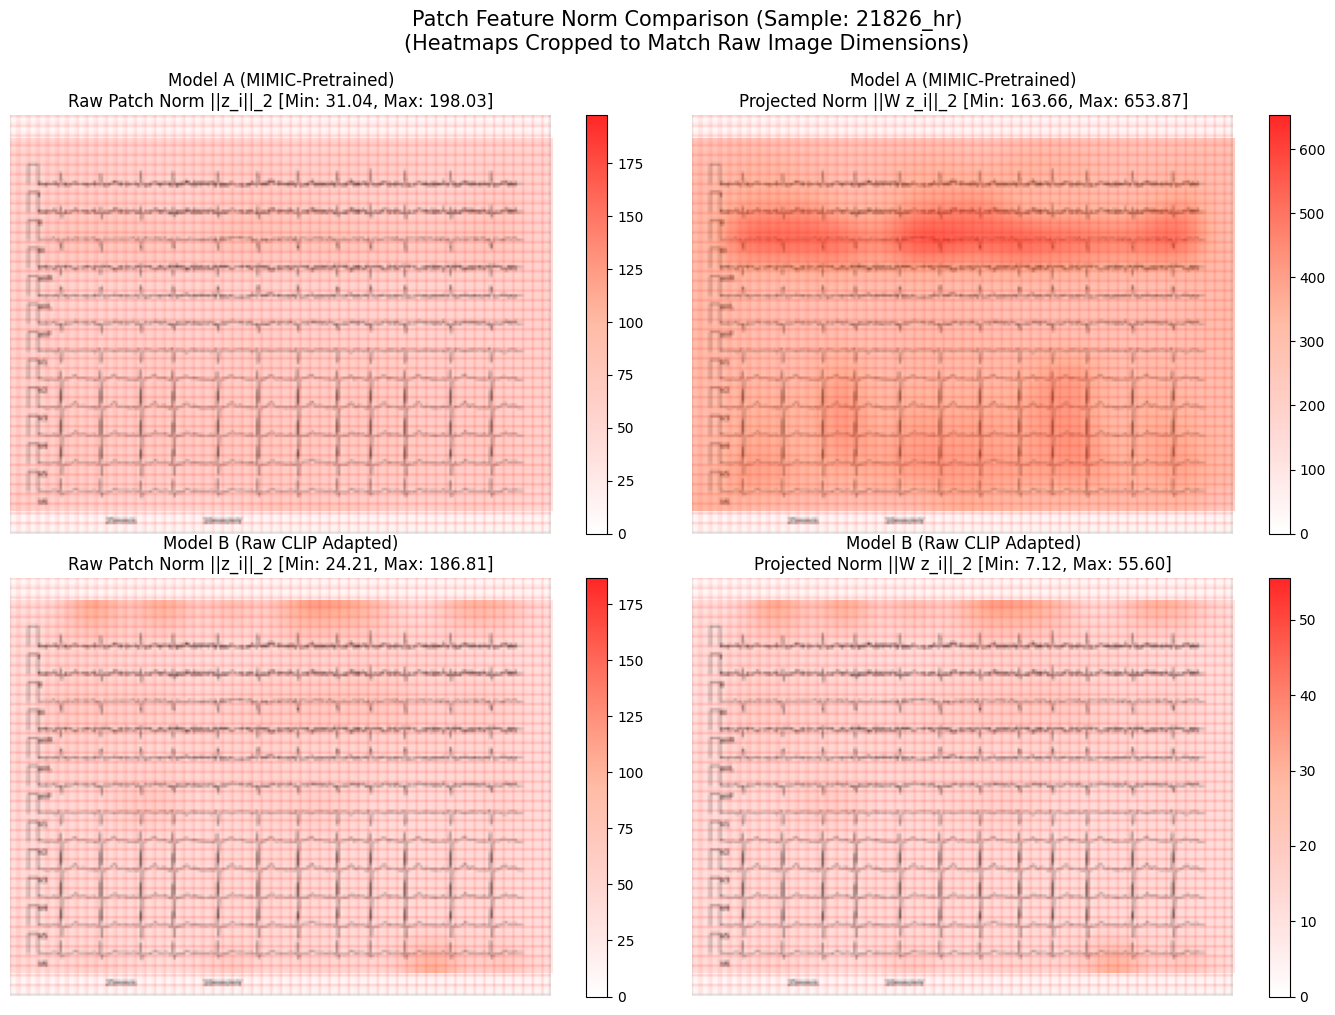

In [46]:
raw_norm_a, proj_norm_a, _ = compute_patch_norms(model_a, image_tensor)
raw_norm_b, proj_norm_b, _ = compute_patch_norms(model_b, image_tensor)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Model A Norms
im_a1 = plot_warm_red_overlay(axes[0, 0], padded_square, raw_norm_a.reshape(grid_size, grid_size), raw_shape=raw_image.size)
axes[0, 0].set_title(f'Model A (MIMIC-Pretrained)\nRaw Patch Norm ||z_i||_2 [Min: {raw_norm_a.min():.2f}, Max: {raw_norm_a.max():.2f}]')
fig.colorbar(im_a1, ax=axes[0, 0])

im_a2 = plot_warm_red_overlay(axes[0, 1], padded_square, proj_norm_a.reshape(grid_size, grid_size), raw_shape=raw_image.size)
axes[0, 1].set_title(f'Model A (MIMIC-Pretrained)\nProjected Norm ||W z_i||_2 [Min: {proj_norm_a.min():.2f}, Max: {proj_norm_a.max():.2f}]')
fig.colorbar(im_a2, ax=axes[0, 1])

# Model B Norms
im_b1 = plot_warm_red_overlay(axes[1, 0], padded_square, raw_norm_b.reshape(grid_size, grid_size), raw_shape=raw_image.size)
axes[1, 0].set_title(f'Model B (Raw CLIP Adapted)\nRaw Patch Norm ||z_i||_2 [Min: {raw_norm_b.min():.2f}, Max: {raw_norm_b.max():.2f}]')
fig.colorbar(im_b1, ax=axes[1, 0])

im_b2 = plot_warm_red_overlay(axes[1, 1], padded_square, proj_norm_b.reshape(grid_size, grid_size), raw_shape=raw_image.size)
axes[1, 1].set_title(f'Model B (Raw CLIP Adapted)\nProjected Norm ||W z_i||_2 [Min: {proj_norm_b.min():.2f}, Max: {proj_norm_b.max():.2f}]')
fig.colorbar(im_b2, ax=axes[1, 1])

plt.suptitle(f'Patch Feature Norm Comparison (Sample: {study_id})\n(Heatmaps Cropped to Match Raw Image Dimensions)', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 3. Side-by-Side Diagnostic Phrase Alignment Heatmaps

Direct visual comparison of cross-attention heatmaps for the ground truth phrase (`inferior myocardial infarction`).

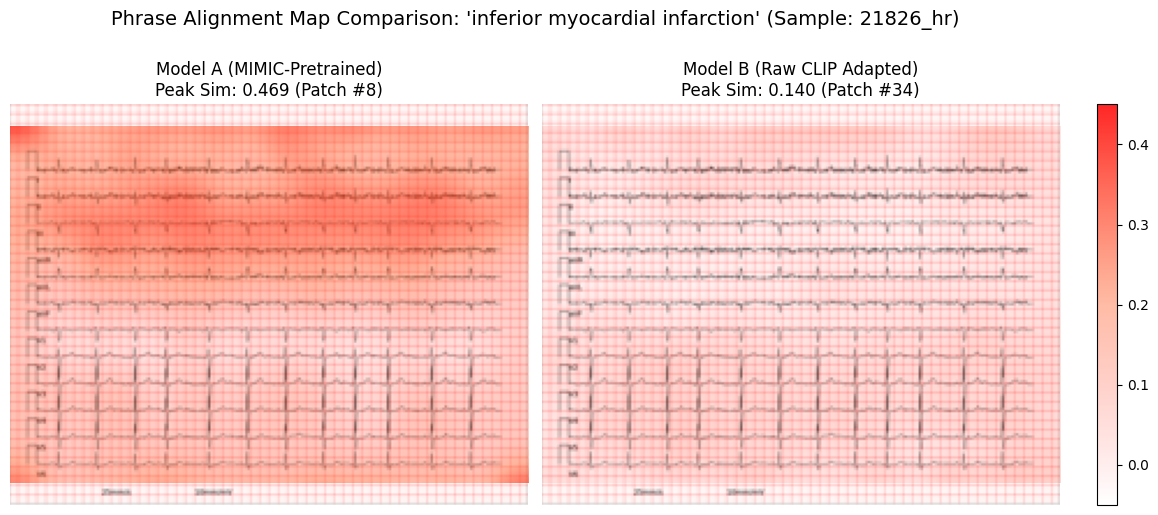

In [47]:
target_phrases = gt_full_descriptions if gt_full_descriptions else ['inferior myocardial infarction']

for phrase in target_phrases:
    sim_a = compute_phrase_level_patch_similarity(model_a, tokenizer, image_tensor, phrase, device=device)
    sim_b = compute_phrase_level_patch_similarity(model_b, tokenizer, image_tensor, phrase, device=device)
    
    map_a = sim_a['similarity_map'].reshape(grid_size, grid_size)
    map_b = sim_b['similarity_map'].reshape(grid_size, grid_size)
    
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
    
    im1 = plot_warm_red_overlay(axes[0], padded_square, map_a, vmin=-0.05, vmax=0.45, raw_shape=raw_image.size)
    axes[0].set_title(f"Model A (MIMIC-Pretrained)\nPeak Sim: {sim_a['max']:.3f} (Patch #{sim_a.get('max_patch_idx', int(np.argmax(sim_a['similarity_map'])))})")
    # fig.colorbar(im1, ax=axes[0])
    
    im2 = plot_warm_red_overlay(axes[1], padded_square, map_b, vmin=-0.05, vmax=0.45, raw_shape=raw_image.size)
    axes[1].set_title(f"Model B (Raw CLIP Adapted)\nPeak Sim: {sim_b['max']:.3f} (Patch #{sim_b.get('max_patch_idx', int(np.argmax(sim_b['similarity_map'])))})")
    fig.colorbar(im2, ax=axes[1])  # Make sure this one is commented out too
    
    # --- Option 3: Pull subplots toward each other ---
    axes[0].set_anchor('E')  # Pull left plot to the right edge of its slot
    axes[1].set_anchor('W')  # Pull right plot to the left edge of its slot
    
    plt.suptitle(f"Phrase Alignment Map Comparison: '{phrase}' (Sample: {study_id})", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.02)  # Place AFTER tight_layout so tight_layout doesn't reset wspace
    plt.show()


## 4. Side-by-Side Dynamic Lead ROI Masking Comparison

Applies the dynamic aspect-ratio lead ROI mask (from Notebook 05) to eliminate non-lead margin patches.

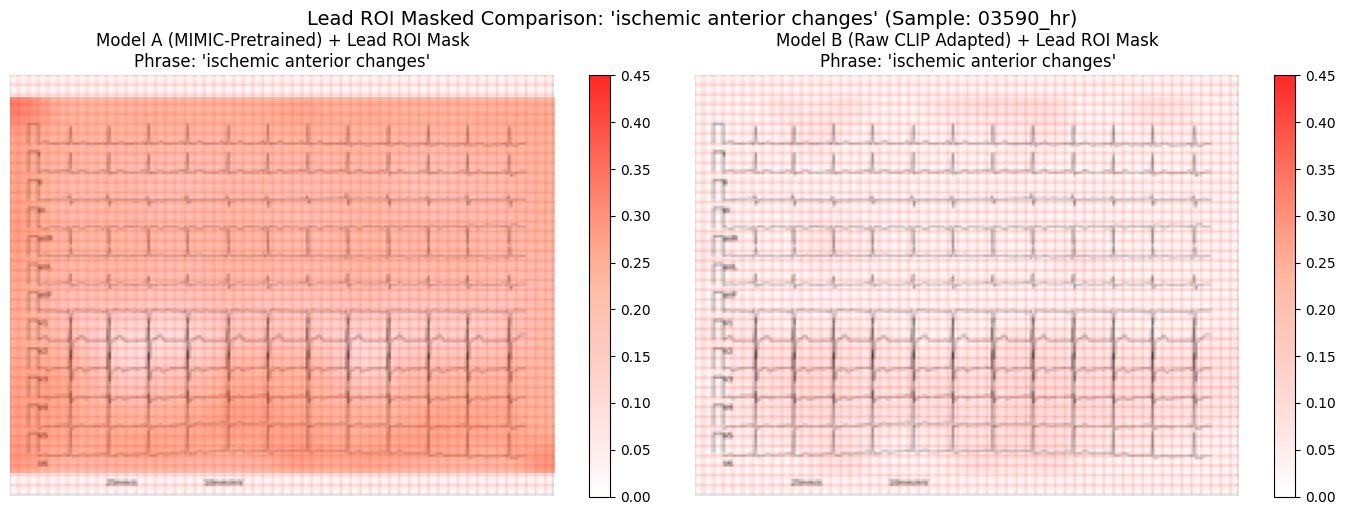

In [5]:
roi_mask = create_ecg_lead_roi_mask(image_size=image_size, patch_size=patch_size, raw_shape=raw_image.size)

for phrase in target_phrases:
    sim_a = compute_phrase_level_patch_similarity(model_a, tokenizer, image_tensor, phrase, device=device)
    sim_b = compute_phrase_level_patch_similarity(model_b, tokenizer, image_tensor, phrase, device=device)
    
    masked_a = apply_roi_mask_to_similarity(sim_a['similarity_map'].reshape(grid_size, grid_size), roi_mask, fill_value=0.0)
    masked_b = apply_roi_mask_to_similarity(sim_b['similarity_map'].reshape(grid_size, grid_size), roi_mask, fill_value=0.0)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    im1 = plot_warm_red_overlay(axes[0], padded_square, masked_a, vmin=0.0, vmax=0.45, raw_shape=raw_image.size)
    axes[0].set_title(f"Model A (MIMIC-Pretrained) + Lead ROI Mask\nPhrase: '{phrase}'")
    fig.colorbar(im1, ax=axes[0])
    
    im2 = plot_warm_red_overlay(axes[1], padded_square, masked_b, vmin=0.0, vmax=0.45, raw_shape=raw_image.size)
    axes[1].set_title(f"Model B (Raw CLIP Adapted) + Lead ROI Mask\nPhrase: '{phrase}'")
    fig.colorbar(im2, ax=axes[1])
    
    plt.suptitle(f"Lead ROI Masked Comparison: '{phrase}' (Sample: {study_id})", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

## 5. Text-Independent Hotspot Test Comparison

Tests whether the peak winning patch is invariant to text prompt across 8 unrelated medical terms.

Model A Most Frequent Winning Patch: #248 (Winning Frequency: 37.5%)
Model B Most Frequent Winning Patch: #72 (Winning Frequency: 12.5%)


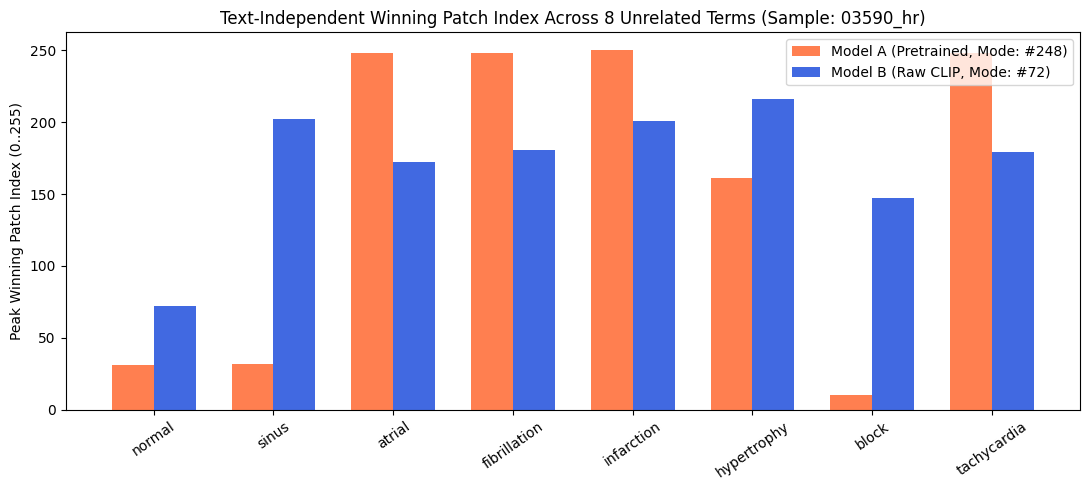

In [6]:
test_terms = ['normal', 'sinus', 'atrial', 'fibrillation', 'infarction', 'hypertrophy', 'block', 'tachycardia']

indep_a, patch_a, freq_a = run_text_independence_test(model_a, tokenizer, image_tensor, test_terms, device=device)
indep_b, patch_b, freq_b = run_text_independence_test(model_b, tokenizer, image_tensor, test_terms, device=device)

print('=' * 75)
print(f'Model A Most Frequent Winning Patch: #{patch_a} (Winning Frequency: {freq_a*100:.1f}%)')
print(f'Model B Most Frequent Winning Patch: #{patch_b} (Winning Frequency: {freq_b*100:.1f}%)')
print('=' * 75)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(test_terms))
width = 0.35

patches_a = [indep_a[t]['max_patch_idx'] for t in test_terms]
patches_b = [indep_b[t]['max_patch_idx'] for t in test_terms]

ax.bar(x - width/2, patches_a, width, label=f'Model A (Pretrained, Mode: #{patch_a})', color='coral')
ax.bar(x + width/2, patches_b, width, label=f'Model B (Raw CLIP, Mode: #{patch_b})', color='royalblue')
ax.set_xticks(x)
ax.set_xticklabels(test_terms, rotation=35)
ax.set_ylabel('Peak Winning Patch Index (0..255)')
ax.set_title(f'Text-Independent Winning Patch Index Across 8 Unrelated Terms (Sample: {study_id})')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Quantitative Contrast & Summary Metrics

Evaluates localization statistics across both models on sample `03579_hr`.

In [7]:
print('=' * 80)
print(f'    ABLATION QUANTITATIVE SUMMARY: PRETRAINED vs. RAW CLIP (Sample: {study_id})')
print('=' * 80)
header_metric = 'Metric / Diagnostic'
header_a = 'Model A (Pretrained)'
header_b = 'Model B (Raw CLIP)'
print(f'{header_metric:<40} | {header_a:<20} | {header_b:<20}')
print('-' * 80)

for phrase in target_phrases:
    p_a = compute_phrase_level_patch_similarity(model_a, tokenizer, image_tensor, phrase, device=device)
    p_b = compute_phrase_level_patch_similarity(model_b, tokenizer, image_tensor, phrase, device=device)
    
    map_a = p_a['similarity_map'].reshape(grid_size, grid_size)
    map_b = p_b['similarity_map'].reshape(grid_size, grid_size)
    
    sig_a = float(map_a[roi_mask].mean())
    bg_a = float(map_a[~roi_mask].mean()) if (~roi_mask).any() else 1e-6
    sig_b = float(map_b[roi_mask].mean())
    bg_b = float(map_b[~roi_mask].mean()) if (~roi_mask).any() else 1e-6
    
    peak_a_str = f"Peak: {p_a['max']:.3f} (Patch #{p_a.get('max_patch_idx', int(np.argmax(p_a['similarity_map'])))})"
    peak_b_str = f"Peak: {p_b['max']:.3f} (Patch #{p_b.get('max_patch_idx', int(np.argmax(p_b['similarity_map'])))})"
    print(f'{phrase[:38]:<40} | {peak_a_str:<20} | {peak_b_str:<20}')
    print(f'  Signal-to-Background Ratio            | {sig_a/bg_a:<20.2f} | {sig_b/bg_b:<20.2f}')
    print(f'  Mean Signal Similarity                 | {sig_a:<20.3f} | {sig_b:<20.3f}')
    print(f'  Mean Background Similarity             | {bg_a:<20.3f} | {bg_b:<20.3f}')

print('=' * 80)

    ABLATION QUANTITATIVE SUMMARY: PRETRAINED vs. RAW CLIP (Sample: 03590_hr)
Metric / Diagnostic                      | Model A (Pretrained) | Model B (Raw CLIP)  
--------------------------------------------------------------------------------
ischemic anterior changes                | Peak: 0.473 (Patch #10) | Peak: 0.085 (Patch #163)
  Signal-to-Background Ratio            | 0.62                 | -0.58               
  Mean Signal Similarity                 | 0.201                | 0.011               
  Mean Background Similarity             | 0.325                | -0.019              


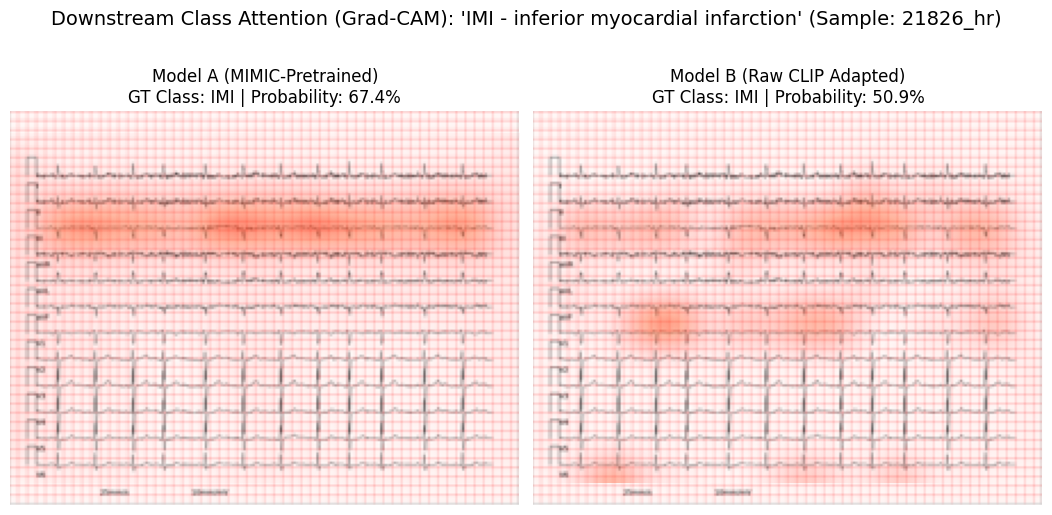

In [48]:
# ==============================================================================
# 3b. Side-by-Side Class Attention (Grad-CAM) Against Ground Truth Class
# Visualizes downstream classifier attention directly on the GT class (e.g. 'IMI')
# ==============================================================================
import torch
import torch.nn.functional as F

target_classes = gt_labels if gt_labels else ['NORM']

def compute_class_gradcam(model, image_tensor, class_idx):
    """Compute Grad-CAM activation map for a specific diagnosis class index."""
    model.eval()
    model.zero_grad()
    
    with torch.enable_grad():
        for p in model.parameters():
            p.requires_grad_(True)
            
        patch_features = model.vision_encoder(image_tensor)  # [1, P, H]
        patch_features.retain_grad()
        
        # Downstream diagnosis prediction
        if hasattr(model, 'diagnosis_head') and model.diagnosis_head is not None:
            if getattr(model, 'diagnosis_from_features', False):
                feature_logits = model.feature_alignment_head(patch_features)[0]
                diag_logits = model.diagnosis_head(feature_logits)
            else:
                pooled = patch_features.mean(dim=1)
                diag_logits = model.diagnosis_head(pooled)
        else:
            raise RuntimeError("Model does not have a diagnosis_head.")
            
        score = diag_logits[0, class_idx]
        score.backward()
        
        # Grad-CAM: Global average pool of gradients as channel weights
        grads = patch_features.grad  # [1, P, H]
        weights = torch.mean(grads, dim=1, keepdim=True)  # [1, 1, H]
        cam = torch.sum(weights * patch_features.detach(), dim=-1)[0]  # [P]
        cam = F.relu(cam).cpu().numpy()
        
        # Normalize activation to [0, 1]
        cam_min, cam_max = cam.min(), cam.max()
        if cam_max > cam_min:
            cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)
            
        prob = torch.sigmoid(diag_logits)[0, class_idx].item()
        
    return cam, prob


for cls_code in target_classes:
    if cls_code not in test_dataset.diagnosis_list:
        continue
    cls_idx = test_dataset.diagnosis_list.index(cls_code)
    expansion = SUBCLASS_DESCRIPTIONS.get(cls_code, cls_code)
    
    # Compute Class Attention for both Model A and Model B
    cam_a, prob_a = compute_class_gradcam(model_a, image_tensor, cls_idx)
    cam_b, prob_b = compute_class_gradcam(model_b, image_tensor, cls_idx)
    
    map_a = cam_a.reshape(grid_size, grid_size)
    map_b = cam_b.reshape(grid_size, grid_size)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    im1 = plot_warm_red_overlay(axes[0], padded_square, map_a, vmin=0.0, vmax=1.0, raw_shape=raw_image.size)
    axes[0].set_title(f"Model A (MIMIC-Pretrained)\nGT Class: {cls_code} | Probability: {prob_a:.1%}")
    
    im2 = plot_warm_red_overlay(axes[1], padded_square, map_b, vmin=0.0, vmax=1.0, raw_shape=raw_image.size)
    axes[1].set_title(f"Model B (Raw CLIP Adapted)\nGT Class: {cls_code} | Probability: {prob_b:.1%}")
    
    # Option 3: Pull subplots together
    axes[0].set_anchor('E')
    axes[1].set_anchor('W')
    
    plt.suptitle(f"Downstream Class Attention (Grad-CAM): '{cls_code} - {expansion}' (Sample: {study_id})", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.02)
    plt.show()
